# Homework 2: Machine Learning for Regression

Machine Learning Zoomcamp 2026 — Module 2

Dataset: `car_fuel_efficiency_2026.csv` 

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../datasets/car_fuel_efficiency_2026.csv")

cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[cols]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA

Does `fuel_efficiency_mpg` have a long tail?

np.float64(0.08080419601878173)

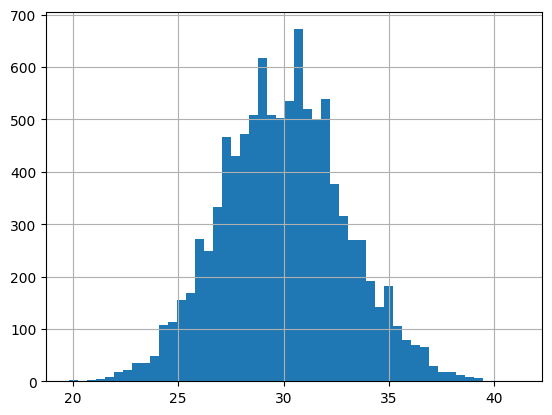

In [ ]:
df['fuel_efficiency_mpg'].hist(bins=50)
df['fuel_efficiency_mpg'].skew()

Skew is close to 0 (~0.08), so the distribution is essentially symmetric, no long tail. That's why this homework doesn't ask for a log transform on the target, unlike some other modules.

## Q1. Column with missing values

There's one column with missing values. Which one?

In [ ]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2. Median horsepower

What's the median (50th percentile) of `horsepower`?

In [ ]:
df['horsepower'].median()

np.float64(254.0)

## Prepare and split the dataset

Shuffle and split 60/20/20, exactly as given in the homework.

In [ ]:
def split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)
    return df_train, df_val, df_test

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    return np.sqrt(se.mean())

feat_cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

df_train, df_val, df_test = split(df, seed=42)
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

## Q3. Fill missing values: 0 vs mean

Train without regularization both ways, compare validation RMSE. Use the training mean only, no peeking at val/test.

In [ ]:
X_train_0 = df_train[feat_cols].fillna(0).values
X_val_0 = df_val[feat_cols].fillna(0).values
w0, w = train_linear_regression(X_train_0, y_train)
y_pred = w0 + X_val_0.dot(w)
rmse_0 = round(rmse(y_val, y_pred), 3)

mean_hp = df_train['horsepower'].mean()
X_train_mean = df_train[feat_cols].fillna(mean_hp).values
X_val_mean = df_val[feat_cols].fillna(mean_hp).values
w0m, wm = train_linear_regression(X_train_mean, y_train)
y_pred_m = w0m + X_val_mean.dot(wm)
rmse_mean = round(rmse(y_val, y_pred_m), 3)

rmse_0, rmse_mean

(np.float64(2.205), np.float64(2.202))

## Q4. Regularized regression

Fill with 0, sweep `r`, find the best RMSE (smallest `r` on ties).

In [ ]:
results = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0r, wr = train_linear_regression_reg(X_train_0, y_train, r=r)
    y_pred_r = w0r + X_val_0.dot(wr)
    results[r] = round(rmse(y_val, y_pred_r), 4)

results

{0: np.float64(2.2053),
 0.01: np.float64(2.2058),
 0.1: np.float64(2.2241),
 1: np.float64(2.3492),
 5: np.float64(2.4094),
 10: np.float64(2.4195),
 100: np.float64(2.4292)}

In [ ]:
best_r = min(results, key=lambda r: (results[r], r))
best_r

0

## Q5. Seed sensitivity

Try seeds 0-9, fill with 0, no regularization. What's the standard deviation of the validation RMSEs?

In [ ]:
scores = []
for seed in range(10):
    df_train_s, df_val_s, df_test_s = split(df, seed)
    y_train_s = df_train_s['fuel_efficiency_mpg'].values
    y_val_s = df_val_s['fuel_efficiency_mpg'].values
    X_train_s = df_train_s[feat_cols].fillna(0).values
    X_val_s = df_val_s[feat_cols].fillna(0).values
    w0s, ws = train_linear_regression(X_train_s, y_train_s)
    y_pred_s = w0s + X_val_s.dot(ws)
    scores.append(rmse(y_val_s, y_pred_s))

round(np.std(scores), 3)

np.float64(0.029)

## Q6. Final model on test set

Seed 9, combine train+val, fill with 0, `r=0.001`. RMSE on test?

In [ ]:
df_train_9, df_val_9, df_test_9 = split(df, seed=9)
df_full_train = pd.concat([df_train_9, df_val_9]).reset_index(drop=True)

y_full_train = df_full_train['fuel_efficiency_mpg'].values
y_test_9 = df_test_9['fuel_efficiency_mpg'].values

X_full_train = df_full_train[feat_cols].fillna(0).values
X_test_9 = df_test_9[feat_cols].fillna(0).values

w0_6, w_6 = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred_test = w0_6 + X_test_9.dot(w_6)
round(rmse(y_test_9, y_pred_test), 3)

np.float64(2.236)